[*********************100%***********************]  2 of 2 completed


(567, 2)
Ticker            TEM        ^GSPC
Date                              
2024-06-14  40.250000  5431.600098
2024-06-17  36.480000  5473.229980
2024-06-18  30.330000  5487.029785
2024-06-20  27.260000  5473.169922
2024-06-21  28.639999  5464.620117
Ticker            TEM        ^GSPC
Date                              
2026-09-14  62.209999  7619.979980
2026-09-15  68.849998  7585.729980
2026-09-16  69.970001  7551.810059
2026-09-17  80.360001  7637.759766
2026-09-18  77.839996  7650.500000
Ticker         TEM       ^GSPC
count   566.000000  566.000000
mean      0.001165    0.000605
std       0.060411    0.010064
min      -0.213625   -0.061609
25%      -0.035266   -0.003797
50%      -0.000769    0.000992
75%       0.035597    0.005772
max       0.304048    0.090895


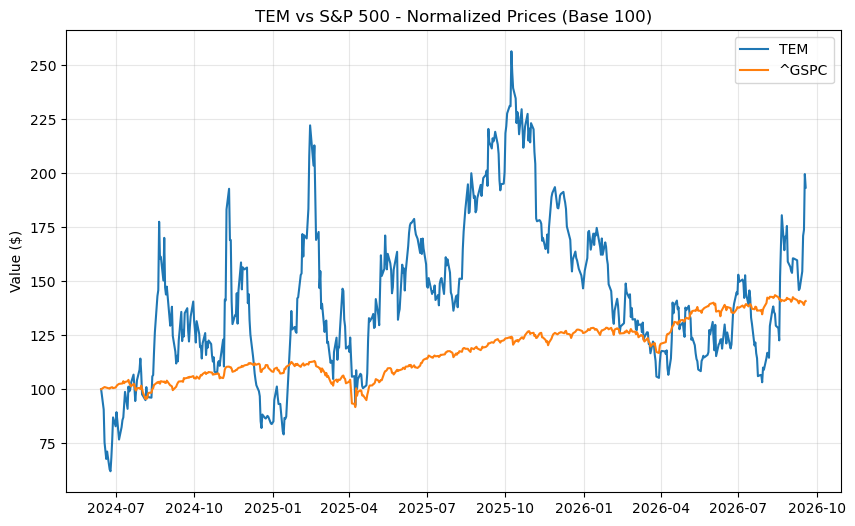

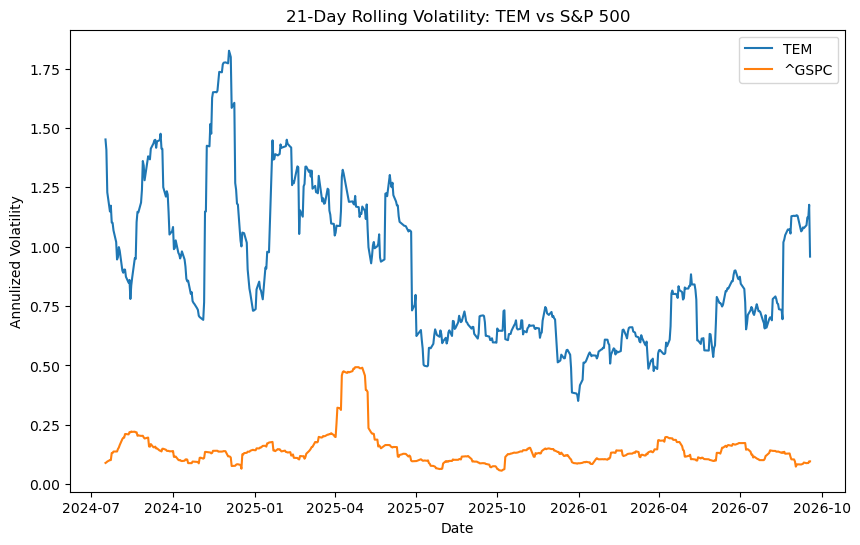


--- Annualized Return ---
TEM: 29.36%
S&P 500: 15.25%

--- Annualized Volatility ---
TEM: 95.90%
S&P 500: 15.98%

--- Covariance ---
Ticker       TEM     ^GSPC
Ticker                    
TEM     0.919663  0.069001
^GSPC   0.069001  0.025525

--- Correlation ---
Ticker      TEM    ^GSPC
Ticker                  
TEM     1.00000  0.45036
^GSPC   0.45036  1.00000
                            OLS Regression Results                            
Dep. Variable:                    TEM   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     143.5
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.28e-29
Time:                        19:07:25   Log-Likelihood:                 850.06
No. Observations:                 566   AIC:                            -1696.
Df Residuals:                     564   BIC:                            -1687.
Df Mo

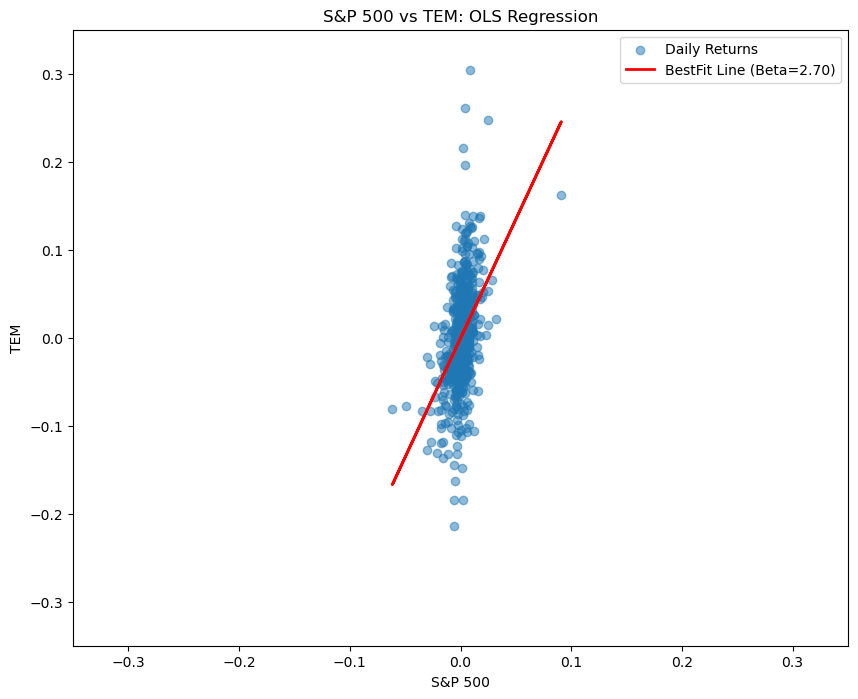

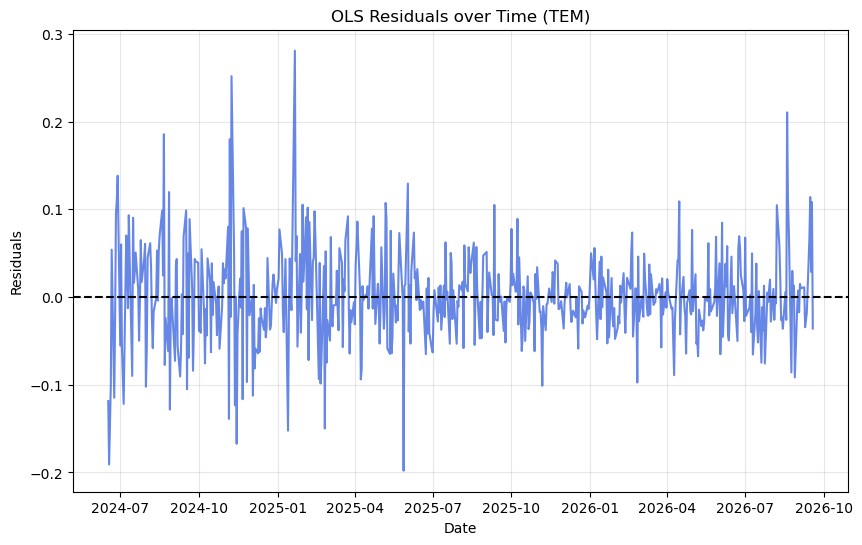


--- Max Drawdown (TEM) ---
Date: 2026-07-29
Log Drawdown: -91.03%
Real Drawdown: -59.76%

 📊 QUANTITATIVE TEAR SHEET: TEM vs S&P 500

[1] RISK & REWARD PROFILE
------------------------------
Annualized Return : TEM 29.36%  |  S&P 500 15.25%
Annual Volatility : TEM 95.90%  |  S&P 500 15.98%
Return/Risk Ratio : TEM 0.31     |  S&P 500 0.95

[2] MARKET EXPOSURE (Systematic Risk)
------------------------------
Correlation w/ Mkt: 0.450
Beta (β)          : 2.70
R-squared (R²)    : 20.3% (Variance explained by S&P 500)

[3] TAIL RISK (Drawdown Analysis)
------------------------------
Max Drawdown      : -59.76%
Trough Date       : 2026-07-29



In [10]:
# Imports
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# Data
TICKERS      = ["TEM", "^GSPC"]
START_DATE   = "2024-06-14"
END_DATE     = "2026-09-20"
TRADING_DAYS = 252

# Download my Data
def compute_data(tickers, start, end):
    data = yf.download(tickers, start=start, end=end , auto_adjust=True)["Close"]
    data = data.dropna()
    
    assert data.index.is_monotonic_increasing
    assert data.isna().sum().sum() == 0
    
    return data

# Log Return
def compute_log_return(data):
    log_return = np.log(data / data.shift(1)).dropna()
    
    return log_return

# Plot Value ($) Chart
def plot_normalized_prices(data):
    normalized_data = (data / data.iloc[0]) * 100
    
    plt.figure(figsize=(10,6))
    plt.plot(normalized_data)
    plt.title("TEM vs S&P 500 - Normalized Prices (Base 100)")
    plt.ylabel("Value ($)")
    plt.legend(normalized_data.columns)
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot Volatility (%) Chart
def plot_rolling_volatility(log_return, window=21):
    rolling_vol = (log_return.rolling(window=window).std() * np.sqrt(TRADING_DAYS)).dropna()
    plt.figure(figsize=(10,6))
    plt.plot(rolling_vol)
    plt.legend(rolling_vol.columns)
    plt.title("21-Day Rolling Volatility: TEM vs S&P 500")
    plt.xlabel("Date")
    plt.ylabel("Annulized Volatility")
    plt.show()

# Annual Mean Return
def compute_annual_return(log_return):
    annual_tem_return = log_return["TEM"].mean() * TRADING_DAYS
    annual_sp500_return = log_return["^GSPC"].mean() * TRADING_DAYS
    
    return annual_tem_return , annual_sp500_return

# Annual Volatility
def compute_annual_volatility(log_return):
    annual_tem_volatility = log_return["TEM"].std() * np.sqrt(TRADING_DAYS)
    annual_sp500_volatility = log_return["^GSPC"].std() * np.sqrt(TRADING_DAYS)
    
    return annual_tem_volatility, annual_sp500_volatility 

# Covariance & Correlation
def compute_covariance_correlation(log_return):
    covariance  = log_return[["TEM", "^GSPC"]].cov() * TRADING_DAYS
    correlation = log_return[["TEM", "^GSPC"]].corr()
    
    return covariance, correlation

# OLS Regression
def compute_ols(X_sp500, Y_tem):
    X_with_const = sm.add_constant(X_sp500)
    reg_model = sm.OLS(Y_tem, X_with_const).fit()
    print(reg_model.summary())
    scipy_model = stats.linregress(X_sp500, Y_tem)
    return reg_model

# Scatter Plot
def plot_regression_scatter(X, Y, reg_model):
    limit = 0.35
    plt.figure(figsize=(10, 8))
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.scatter(X, Y, alpha=0.5, label = "Daily Returns")
    alpha = reg_model.params["const"]
    beta = reg_model.params["^GSPC"]
    Y_pred = alpha + beta * X
    plt.plot(X, Y_pred, color="red", linewidth=2, label=f"BestFit Line (Beta={beta:.2f})")
    plt.xlabel("S&P 500")
    plt.ylabel("TEM")
    plt.title("S&P 500 vs TEM: OLS Regression")
    plt.legend()
    plt.show()

# Residuals
def plot_residuals(reg_model):
    residuals = reg_model.resid
    plt.figure(figsize=(10,6))
    plt.plot(residuals, color="royalblue", alpha=0.8)
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color="black", linestyle="--")
    plt.title("OLS Residuals over Time (TEM)")
    plt.show()
    
#Drawdown
def compute_max_drawdown(log_return_series):
    cumulative = log_return_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    mdd_date = drawdown.idxmin()
    mdd_value = drawdown.min()
    
    return mdd_date, mdd_value

# Final
def print_quant_tear_sheet(annual_tem_ret, annual_sp_ret, annual_tem_vol, annual_sp_vol, covariance, correlation, reg_model, mdd_date, real_drawdown):
    print("\n" + "="*60)
    print(" 📊 QUANTITATIVE TEAR SHEET: TEM vs S&P 500")
    print("="*60)
    
    # 1. Risk & Reward
    print("\n[1] RISK & REWARD PROFILE")
    print("-" * 30)
    print(f"Annualized Return : TEM {annual_tem_ret*100:.2f}%  |  S&P 500 {annual_sp_ret*100:.2f}%")
    print(f"Annual Volatility : TEM {annual_tem_vol*100:.2f}%  |  S&P 500 {annual_sp_vol*100:.2f}%")
    print(f"Return/Risk Ratio : TEM {(annual_tem_ret/annual_tem_vol):.2f}     |  S&P 500 {(annual_sp_ret/annual_sp_vol):.2f}")

    # 2. Market Exposure (Systematic Risk)
    print("\n[2] MARKET EXPOSURE (Systematic Risk)")
    print("-" * 30)
    print(f"Correlation w/ Mkt: {correlation.loc['TEM', '^GSPC']:.3f}")
    print(f"Beta (β)          : {reg_model.params['^GSPC']:.2f}")
    print(f"R-squared (R²)    : {reg_model.rsquared * 100:.1f}% (Variance explained by S&P 500)")
    
    # 3. Tail Risk (Worst Case)
    print("\n[3] TAIL RISK (Drawdown Analysis)")
    print("-" * 30)
    print(f"Max Drawdown      : {real_drawdown*100:.2f}%")
    print(f"Trough Date       : {mdd_date.date()}")
    
    print("="*60 + "\n")
    
if __name__ == "__main__":
    data = compute_data(TICKERS, START_DATE, END_DATE)
    print(data.shape)
    print(data.head())
    print(data.tail())
    
    log_return = compute_log_return(data)
    
    X = log_return["^GSPC"]
    Y = log_return["TEM"]
    
    print(log_return.describe())
    
    plot_normalized_prices(data)
    
    plot_rolling_volatility(log_return)
    
    annual_tem_ret, annual_sp_ret = compute_annual_return(log_return)
    annual_tem_vol, annual_sp_vol = compute_annual_volatility(log_return)
    
    print("\n--- Annualized Return ---")
    print(f"TEM: {annual_tem_ret * 100:.2f}%")
    print(f"S&P 500: {annual_sp_ret * 100:.2f}%")
    
    print("\n--- Annualized Volatility ---")
    print(f"TEM: {annual_tem_vol * 100:.2f}%")
    print(f"S&P 500: {annual_sp_vol * 100:.2f}%")
    
    covariance, correlation = compute_covariance_correlation(log_return)
    print("\n--- Covariance ---")
    print(covariance)
    print("\n--- Correlation ---")
    print(correlation)
    
    model = compute_ols(X, Y)
    
    plot_regression_scatter(X, Y, model)
    plot_residuals(model)
    
    mdd_date, mdd_value = compute_max_drawdown(Y)    
    real_drawdown = (np.exp(mdd_value) - 1)
    print("\n--- Max Drawdown (TEM) ---")
    print(f"Date: {mdd_date.date()}")
    print(f"Log Drawdown: {mdd_value * 100:.2f}%")
    print(f"Real Drawdown: {real_drawdown * 100:.2f}%")
    
    print_quant_tear_sheet(annual_tem_ret, annual_sp_ret, annual_tem_vol, annual_sp_vol, covariance, correlation, model, mdd_date, real_drawdown)